In [ ]:
"""Sharpe benchmark of S&P 500 regime switches: HMM signals vs market strategies."""

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

project_root = Path(__file__).resolve().parents[2]
sys.path.insert(0, str(project_root / "src"))

from model_evaluation.market_strategy import (  # noqa: E402  (needs path setup)
    apply_weights,
    buy_and_hold,
    compare_strategies,
    hmmlearn_causal_probabilities,
    moving_average_timing,
    plot_equity_curves,
    plot_regime_overlay,
    regime_probability_scaled,
    regime_threshold,
    volatility_target,
)

DATA_PATH = project_root / "data/processed/sp500_index_price.csv"
MAX_ITER, TOL = 120, 1e-3
MIN_COVAR = 1e-5
"""Floor on per-state variances; mirrors the local package's ``MIN_VARIANCE``."""

N_STATES = 3
VOLATILITY_DAYS, MOMENTUM_DAYS = 60, 20
N_RESTARTS = 10
"""Baum-Welch is non-convex; keep the best-likelihood of 10 seeds."""

COST_BPS = 5.0
"""Transaction cost in basis points per unit of strategy turnover."""

'Transaction cost in basis points per unit of strategy turnover.'

In [ ]:
data = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"]).sort_values("YYYYMMDD")
prices = data.set_index("YYYYMMDD")["DlyPrcInd"]
returns = np.log(prices).diff().dropna().rename("r_t")

training = returns.loc["1988":"1997"]     # 10 training years, 1998 excluded
validation = returns.loc["1998":"1999"]   # avoid 2000 for now
test = returns.loc["2001"]

if any(series.empty for series in (validation, training, test)):
    raise ValueError("A requested period is empty")
if (len(training.index.year.unique()) != 10
        or test.index.year.unique().tolist() != [2001]):
    raise ValueError("Expected ten training years and 2001 evaluation")

## Features: r_t, sigma_t, m_t

transformed = pd.concat(
    [
        returns.rename("r_t"),
        returns.rolling(VOLATILITY_DAYS, min_periods=VOLATILITY_DAYS)
        .std(ddof=1)
        .rename("sigma_t"),
        returns.rolling(MOMENTUM_DAYS, min_periods=MOMENTUM_DAYS)
        .mean()
        .rename("m_t"),
    ],
    axis=1,
)

transformed_train = transformed.loc[training.index]

print(f"Validation: {len(validation)} days")
print(f"Full training: {len(training)} days; held-out 2001: {len(test)} days")

logging.getLogger("hmmlearn").setLevel(logging.ERROR)  # drop per-restart noise

Validation: 504 days
Full training: 2529 days; held-out 2001: 248 days


In [ ]:
def fit_hmmlearn(X: np.ndarray, n_states: int) -> GaussianHMM:
    """Fit a Gaussian HMM over N_RESTARTS seeds, keeping the best likelihood.

    Restarts where EM starves a state produce NaN parameters in hmmlearn
    (0/0 in the M-step); ``score()`` then raises, so those seeds are skipped.

    Args:
        X: Feature matrix, one row per day: ``[r_t, sigma_t, m_t]``.
        n_states: Number of hidden states.

    Returns:
        The fitted model with the highest total log-likelihood.

    Raises:
        RuntimeError: Every restart collapsed to NaN parameters.
    """
    best, best_score = None, -np.inf
    for seed in range(N_RESTARTS):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type="full",
            min_covar=MIN_COVAR,
            n_iter=MAX_ITER,
            tol=TOL,
            random_state=seed,
        )
        try:
            model.fit(X)
            score = model.score(X)
        except ValueError:  # NaN/inf parameters from a collapsed state
            continue
        if np.isfinite(score) and score > best_score:
            best, best_score = model, score
    if best is None:
        raise RuntimeError(
            f"All {N_RESTARTS} restarts collapsed for n_states={n_states}"
        )
    return best


X_train = transformed_train.to_numpy()   # (T, 3): r_t, sigma_t, m_t
model = fit_hmmlearn(X_train, N_STATES)

fitted = pd.DataFrame(
    {
        "mean_r": model.means_[:, 0],
        "sd_r": np.sqrt(model.covars_[:, 0, 0]),
        "mean_sigma": model.means_[:, 1],
    }
)
high_state = int(fitted["sd_r"].idxmax())  # state with the fatter return distribution
print(fitted.round(4))
print(np.round(model.transmat_, 3))
print(
    f"converged={model.monitor_.converged} "
    f"in {len(model.monitor_.history) - 1} EM iterations"
)

## Model selection: AIC / BIC from the HMM itself (lower is better)

selection = []
for k in (2, N_STATES):
    fitted_k = fit_hmmlearn(X_train, k)
    n_params = sum(fitted_k._get_n_fit_scalars_per_param().values())
    selection.append(
        {
            "n_states": k,
            "logL/day (train)": fitted_k.score(X_train) / len(X_train),
            "n_params": n_params,
            "AIC (train)": fitted_k.aic(X_train),
            "BIC (train)": fitted_k.bic(X_train),
        }
    )
selection = pd.DataFrame(selection).set_index("n_states")
print(selection.round(3))

## Held-out likelihood vs an iid-Gaussian baseline fitted on train only

rows = []
mu0, sd0 = training.mean(), training.std(ddof=1)
for name, split in [("train", training), ("val", validation), ("test", test)]:
    X = transformed.loc[split.index].to_numpy()
    hmm_nll = -model.score(X) / len(X)  # score() is total log-likelihood
    gauss_nll = (
        0.5 * np.log(2 * np.pi * sd0**2) + 0.5 * ((split - mu0) / sd0) ** 2
    ).mean()
    rows.append({"split": name, "HMM NLL/day": hmm_nll, "Gaussian NLL/day": gauss_nll})
metrics = pd.DataFrame(rows).set_index("split")
print(metrics.round(5))

/Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/.venv/lib/python3.10/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])
/Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/.venv/lib/python3.10/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


   mean_r    sd_r  mean_sigma
0 -0.0001  0.0108      0.0104
1  0.0008  0.0070      0.0067
2 -0.0000  0.0205      0.0174
[[0.964 0.026 0.011]
 [0.007 0.992 0.001]
 [0.062 0.    0.938]]
converged=True in 15 EM iterations


/Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/.venv/lib/python3.10/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])
/Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/.venv/lib/python3.10/site-packages/hmmlearn/hmm.py:352: RuntimeWarning: invalid value encountered in divide
  self.means_ = ((means_weight * means_prior + stats['obs'])


          logL/day (train)  n_params  AIC (train)  BIC (train)
n_states                                                      
2                   12.962        21   -65517.471   -65394.924
3                   13.099        35   -66183.838   -65979.592
       HMM NLL/day  Gaussian NLL/day
split                               
train    -13.09882          -3.37706
val      -12.10265          -2.80612
test     -11.26851          -2.52278



Strategy benchmark 1998-01-02 .. 2001-12-31 (frozen 1988-1997 fit, causal signals, 5 bps per turnover):
               years  total_return  ann_return  ann_volatility  sharpe  sortino  max_drawdown  calmar  hit_rate  exposure  turnover_per_year
ma_50_200      3.984         0.165       0.038           0.137   0.280    0.304        -0.129   0.297     0.233     0.471              1.004
buy_and_hold   3.984         0.182       0.042           0.206   0.204    0.303        -0.368   0.114     0.506     1.000              0.000
regime_cut     3.984        -0.057      -0.015           0.161  -0.092   -0.124        -0.368  -0.040     0.505     0.810              5.095
regime_scaled  3.984        -0.069      -0.018           0.159  -0.113   -0.157        -0.372  -0.049     0.504     0.811              5.754
vol_target_60  3.984        -0.129      -0.035           0.155  -0.223   -0.308        -0.337  -0.103     0.471     0.734              2.672


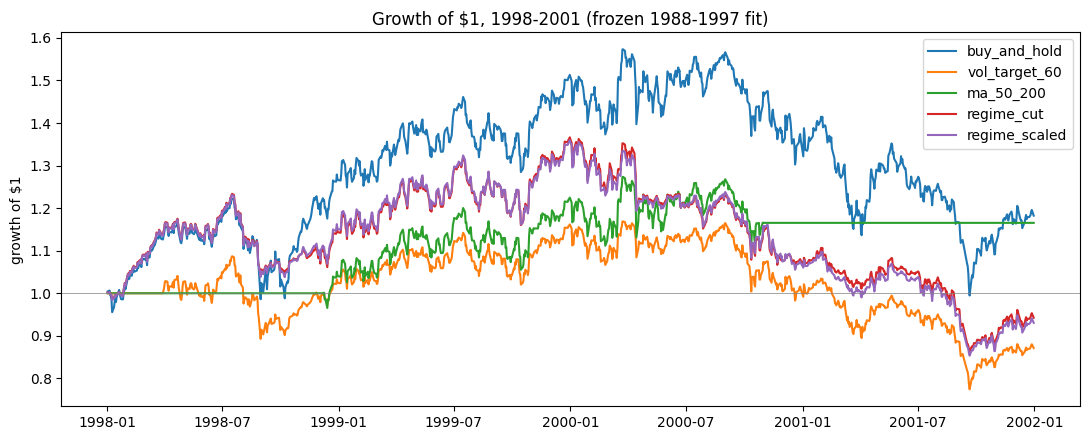

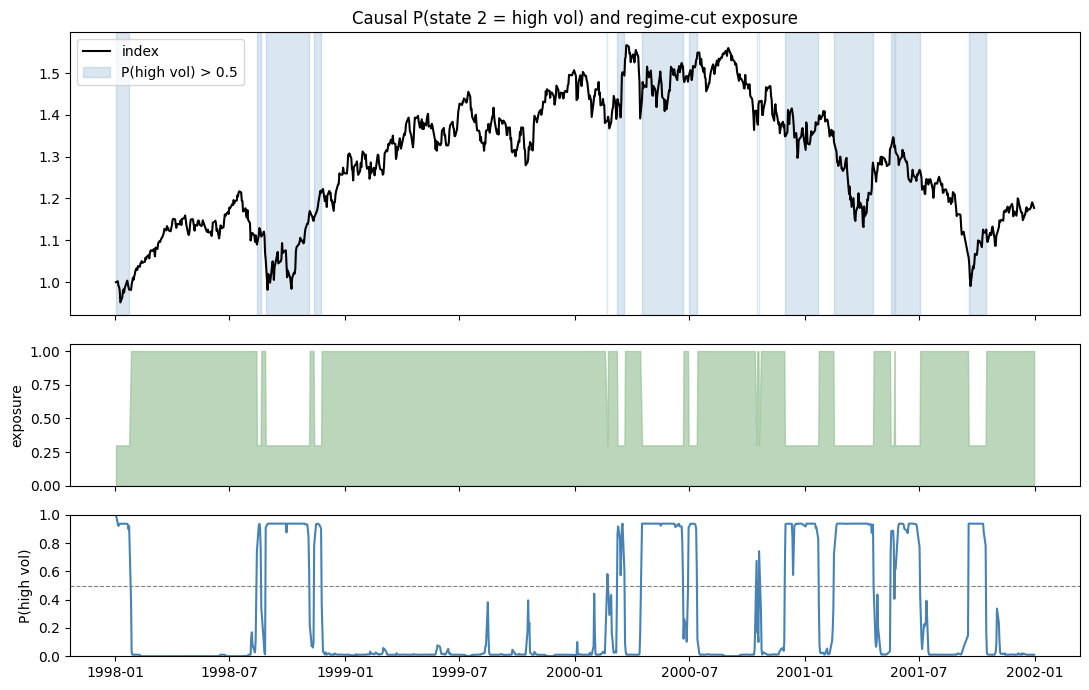

In [ ]:
## Strategy benchmark: zero-signal baselines vs HMM-signal strategies

# CAUSALITY: signals are one-step-ahead probabilities, never smoothed
# predict_proba - the position for day t uses data through t-1 only.
# Window is contiguous 1998-2001; 2000 stays in as crash stress (rolling
# features need continuity; the likelihood sections keep val/test separate).
evaluation = returns.loc["1998":"2001"]
proba_causal = hmmlearn_causal_probabilities(
    model, transformed.loc[evaluation.index].to_numpy()
)
p_high = pd.Series(proba_causal[:, high_state], index=evaluation.index)

weights = {
    "buy_and_hold": buy_and_hold(evaluation),
    "vol_target_60": volatility_target(evaluation, days=60, target_volatility=0.15),
    "ma_50_200": moving_average_timing(
        prices.loc[evaluation.index], fast=50, slow=200
    ),
    "regime_cut": regime_threshold(p_high, high_exposure=0.3, low_exposure=1.0),
    "regime_scaled": regime_probability_scaled(
        p_high, high_exposure=0.3, low_exposure=1.0
    ),
}
results = {
    name: apply_weights(evaluation, w, cost_bps=COST_BPS)
    for name, w in weights.items()
}
print(
    f"\nStrategy benchmark {evaluation.index[0].date()} .. "
    f"{evaluation.index[-1].date()} "
    f"(frozen 1988-1997 fit, causal signals, {COST_BPS:.0f} bps per turnover):"
)
print(compare_strategies(results, weights).round(3).to_string())

plot_equity_curves(results, title="Growth of $1, 1998-2001 (frozen 1988-1997 fit)")
plot_regime_overlay(
    prices.loc[evaluation.index],
    weights["regime_cut"],
    p_high,
    title=f"Causal P(state {high_state} = high vol) and regime-cut exposure",
)
plt.show()